In [1]:
# =========================================================
# LSTM for RUL Prediction
# =========================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================

# Python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Ignore Unimportant Ignores
import warnings
warnings.filterwarnings('ignore')

2026-05-26 16:52:49.719443: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779814369.993038      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779814370.077816      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779814370.775584      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779814370.775641      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779814370.775644      16 computation_placer.cc:177] computation placer alr

In [2]:
# =========================
# 2. LOAD DATA
# =========================

train_path = '/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/train_FD001.txt'
test_path = '/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/test_FD001.txt'
rul_path = '/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/RUL_FD001.txt'

df_train = pd.read_csv(train_path, sep='\s+', header=None)
df_test = pd.read_csv(test_path, sep='\s+', header=None)
df_rul = pd.read_csv(rul_path, sep='\s+', header=None, names=['RUL'])

print("Train Shape:", df_train.shape)
print("Test Shape :", df_test.shape)

# =========================
# 3. COLUMN NAMES
# =========================

column_names = ['unit_number','time_cycles','op_setting_1','op_setting_2','op_setting_3']

for i in range(1, 22):
    column_names.append(f'sensor_{i}')

df_train.columns = column_names
df_test.columns = column_names

# =========================
# 4. REMOVE CONSTANT COLUMNS
# =========================

constant_cols = []

for col in df_train.columns:

    if (df_train[col].nunique() == 1
        and col not in ['unit_number', 'time_cycles']):
        constant_cols.append(col)

df_train.drop(columns=constant_cols, inplace=True)
df_test.drop(columns=constant_cols, inplace=True)

print("\nRemoved Constant Columns:")
print(constant_cols)

Train Shape: (20631, 26)
Test Shape : (13096, 26)

Removed Constant Columns:
['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


In [3]:
# =========================
# 5. CALCULATE RUL
# =========================

max_cycles = (df_train.groupby('unit_number')['time_cycles'].max().reset_index())
max_cycles.columns = ['unit_number', 'max_cycle']

df_train = df_train.merge(max_cycles,on='unit_number',how='left')
df_train['RUL'] = (df_train['max_cycle']- df_train['time_cycles'])

# =========================
# 6. OPTIONAL RUL CLIPPING
# =========================

RUL_THRESHOLD = 153

df_train['RUL'] = df_train['RUL'].clip(upper=RUL_THRESHOLD)

# =========================
# 7. FEATURE COLUMNS
# =========================

feature_cols = [

    col for col in df_train.columns

    if col not in ['unit_number','time_cycles','max_cycle','RUL']]

print("\nNumber of Features:", len(feature_cols))


Number of Features: 17


In [4]:
# =========================
# 8. SCALING
# =========================

scaler = StandardScaler()

train_scaled = scaler.fit_transform(df_train[feature_cols])
test_scaled = scaler.transform(df_test[feature_cols])

df_train_scaled = df_train.copy()
df_test_scaled = df_test.copy()

df_train_scaled[feature_cols] = train_scaled
df_test_scaled[feature_cols] = test_scaled

# =========================
# 9. CREATE SEQUENCES
# =========================

WINDOW_SIZE = 30

def create_sequences(df, feature_cols, window_size):

    X = []
    y = []

    for unit in df['unit_number'].unique():

        unit_df = df[df['unit_number'] == unit]

        data = unit_df[feature_cols].values
        rul = unit_df['RUL'].values

        for i in range(len(unit_df) - window_size):

            X.append(data[i:i + window_size])
            y.append(rul[i + window_size])

    return np.array(X), np.array(y)

# CREATE TRAIN SEQUENCES

X_train, y_train = create_sequences(df_train_scaled,feature_cols,WINDOW_SIZE)

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (17631, 30, 17)
y_train shape: (17631,)


In [5]:
# =========================
# 10. CREATE TEST SEQUENCES
# =========================

X_test = []

for unit in df_test_scaled['unit_number'].unique():

    unit_df = df_test_scaled[df_test_scaled['unit_number'] == unit]
    data = unit_df[feature_cols].values

    # Last 30 cycles
    sequence = data[-WINDOW_SIZE:]
    X_test.append(sequence)

X_test = np.array(X_test)
y_test = df_rul['RUL'].values

print("\nX_test shape:", X_test.shape)

# =========================
# 11. BUILD LSTM MODEL
# =========================

model = Sequential()

# First LSTM Layer
model.add(LSTM(64,return_sequences=True,input_shape=(WINDOW_SIZE,len(feature_cols))))
model.add(Dropout(0.3))

# Second LSTM Layer
model.add(LSTM(32,return_sequences=False))
model.add(Dropout(0.4))

# Dense Layers
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))

# Output Layer
model.add(Dense(1))



# =========================
# 12. COMPILE MODEL
# =========================

model.compile(optimizer='adam',loss='mse',metrics=['mae'])

# =========================
# 13. MODEL SUMMARY
# =========================

print("\nMODEL SUMMARY")
model.summary()

# =========================
# 14. EARLY STOPPING
# =========================

early_stop = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

# =========================
# 15. TRAIN MODEL
# =========================

history = model.fit(X_train,y_train,epochs=40,batch_size=64,validation_split=0.2,callbacks=[early_stop],verbose=1)

# =========================
# 16. PREDICTIONS
# =========================

predictions = model.predict(X_test)
predictions = predictions.flatten()

# Prevent negative values
predictions = np.maximum(predictions, 0)

# =========================
# 17. EVALUATION
# =========================

rmse = np.sqrt(mean_squared_error(y_test,predictions))
mae = mean_absolute_error(y_test,predictions)

print("\n==============================")
print("FINAL RESULTS")
print("==============================")

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")


X_test shape: (100, 30, 17)


2026-05-26 16:53:20.260879: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,633 (147.00 KB)

 Trainable params: 37,633 (147.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
221/221 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - loss: 5961.4468 - mae: 61.3617 - val_loss: 633.4575 - val_mae: 20.8745
Epoch 2/40
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 627.7887 - mae: 19.1489 - val_loss: 489.3846 - val_mae: 18.3070
Epoch 3/40
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 488.3115 - mae: 16.5885 - val_loss: 532.9388 - val_mae: 18.7135
Epoch 4/40
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 424.8318 - mae: 15.3473 - val_loss: 483.5495 - val_mae: 17.2875
Epoch 5/40
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 378.2724 - mae: 14.5151 - val_loss: 493.5749 - val_mae: 17.7802
Epoch 6/40
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 317.3806 - mae: 13.2960 - val_loss: 526.1617 - val_mae: 18.3326
Epoch 7/40
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 279.8531 - mae: 12.4651 - val_loss: 580.9207 - val_mae: 19.0649
Epoch 8/40
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 245.7999 - mae: 11.6725 - val_loss: 632.1419 - val_mae: 19.723

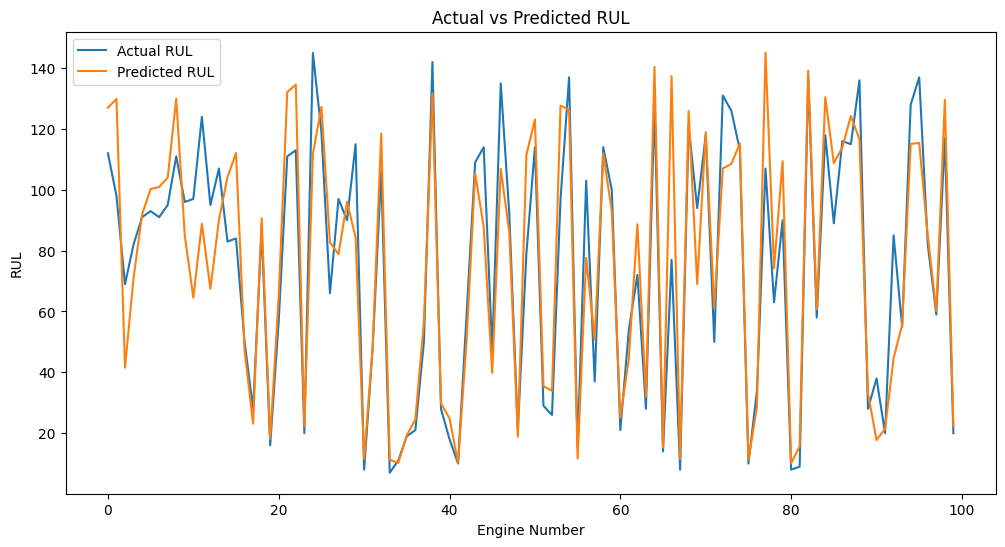

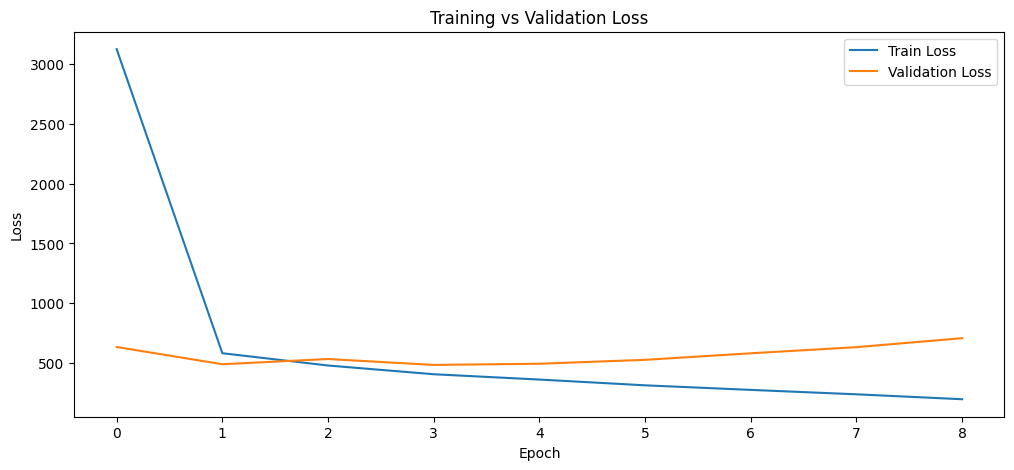

In [6]:
# =========================
# 18. VISUALIZATION
# =========================

plt.figure(figsize=(12,6))
plt.plot(y_test,label='Actual RUL')
plt.plot(predictions,label='Predicted RUL')
plt.xlabel('Engine Number')
plt.ylabel('RUL')
plt.title('Actual vs Predicted RUL')
plt.legend()
plt.show()

# =========================
# 19. TRAINING HISTORY
# =========================

plt.figure(figsize=(12,5))
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()
